In [61]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [62]:
to_drop = pd.DataFrame(train_df.dtypes[train_df.dtypes =='object'])
cols_to_drop = (to_drop.index).tolist()
train_df.drop(cols_to_drop, axis = 1, inplace = True)
test_df.drop(cols_to_drop, axis = 1, inplace=True)

In [63]:
to_drop = pd.DataFrame(train_df.dtypes[train_df.dtypes =='float'])
cols_to_drop = (to_drop.index).tolist()
train_df.drop(cols_to_drop, axis = 1, inplace = True)
test_df.drop(cols_to_drop, axis = 1, inplace=True)

dtype_counts = train_df.dtypes.value_counts()
print(dtype_counts)

int64    35
Name: count, dtype: int64


In [64]:
train_df['Totalbaths'] = train_df['BsmtFullBath'] + train_df['FullBath'] + 0.5 * (train_df['BsmtHalfBath'] + train_df['HalfBath'])
test_df['Totalbaths'] = test_df['BsmtFullBath'] + test_df['FullBath'] + 0.5 * (test_df['BsmtHalfBath'] + test_df['HalfBath'])

In [65]:
train_df['Totalsf'] = train_df['1stFlrSF'] + train_df['2ndFlrSF'] + train_df['BsmtFinSF1'] + train_df['BsmtFinSF2']
test_df['Totalsf'] = test_df['1stFlrSF'] + test_df['2ndFlrSF'] + test_df['BsmtFinSF1'] + test_df['BsmtFinSF2']

In [69]:
test_df.columns

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'Totalbaths',
       'Totalsf'],
      dtype='object')

In [108]:
X_train = train_df[['Totalbaths', 'Totalsf', 'BedroomAbvGr']]
X_test = test_df[['Totalbaths', 'Totalsf', 'BedroomAbvGr']]

y_train = train_df['SalePrice']
y_test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')


In [112]:
y_test.drop('Id', axis = 1, inplace = True)

In [99]:
X_test['Totalbaths'].isnull().sum()

np.int64(0)

In [100]:
X_test.isnull().sum()

Totalbaths      0
Totalsf         0
BedroomAbvGr    0
dtype: int64

In [101]:
X_test['Totalbaths'] = X_test['Totalbaths'].fillna(0)
X_test['Totalsf'] = X_test['Totalsf'].fillna(0)

/tmp/ipykernel_55/761349334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Totalbaths'] = X_test['Totalbaths'].fillna(0)
/tmp/ipykernel_55/761349334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Totalsf'] = X_test['Totalsf'].fillna(0)


In [102]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [106]:
prediction = model.predict(X_test)
prediction = pd.DataFrame(prediction)

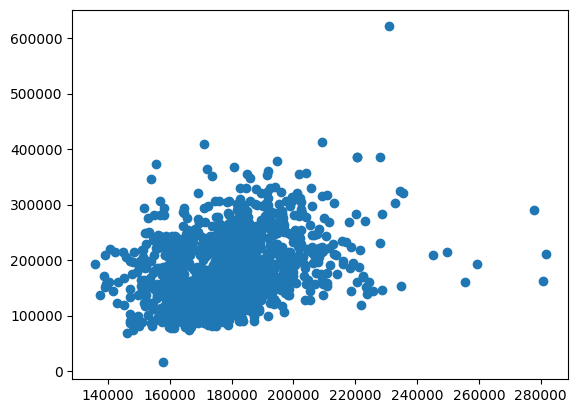

In [113]:
plt.scatter(y_test, prediction)


In [114]:
from sklearn.metrics import mean_squared_error

In [115]:
mean_squared_error(y_test , prediction)

3053475610.647143